# 02_eda.ipynb
## Project: Malaysia Unemployment Analysis
### Notebook 02: Exploratory Data Analysis (EDA)
**Author:** TzePing + Grok  
**Date:** 12 March 2026  
**Description:** Clean analysis on processed data from 01_data_ingestion.ipynb.  
Focus: Unemployment trends, COVID impact, sector changes, and key economic insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ====================== CONFIG ======================
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')

# ====================== PATHS (from ingestion) ======================
ROOT = Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"#we locate a folder using path lib 
#then we can directly call this folder and read the data set file
#(this is a folder only not the file)

IMAGE_DIR_02 = ROOT / "image_chart_02_eda"

# Create image folder if missing
IMAGE_DIR_02.mkdir(parents=True, exist_ok=True)


In [2]:
# ====================== 1. LOAD CLEAN DATA ======================
df_malaysia = pd.read_csv(DATA_PROCESSED / "malaysia_clean.csv") #here is read the data set(file) use pathlib to call the folder 
#(so here we call that folder and /(filename))

df__malaysia_10years = df_malaysia[df_malaysia["Year"].between(2012,2022)]

print(f" Loaded clean Malaysia data: {df__malaysia_10years.shape[0]} rows x {df__malaysia_10years.shape[1]} columns")
print("\nColumns:\n", df__malaysia_10years.columns.tolist())
df__malaysia_10years.head()

 Loaded clean Malaysia data: 11 rows x 9 columns

Columns:
 ['Country Name', 'Year', 'Employment Sector: Agriculture', 'Employment Sector: Industry', 'Employment Sector: Services', 'Unemployment Rate', 'GDP (billion USD)', 'covid_period', 'unemp_change_pct']


,Country Name,Year,Employment Sector: Agriculture,Employment Sector: Industry,Employment Sector: Services,Unemployment Rate,GDP (billion USD),covid_period,unemp_change_pct
21,Malaysia,2012,13.300,27.600,59.200,3.100,314.440,0,0.050
22,Malaysia,2013,12.700,27.900,59.400,3.160,323.280,0,0.060
23,Malaysia,2014,12.600,27.700,59.700,2.880,338.070,0,-0.280
24,Malaysia,2015,12.500,27.500,60.000,3.100,301.360,0,0.220
25,Malaysia,2016,11.400,27.500,61.100,3.440,301.260,0,0.340


In [3]:
print(" Basic Info ")
print()
display(df__malaysia_10years.info())

 Basic Info 

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 21 to 31
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country Name                    11 non-null     str    
 1   Year                            11 non-null     int64  
 2   Employment Sector: Agriculture  11 non-null     float64
 3   Employment Sector: Industry     11 non-null     float64
 4   Employment Sector: Services     11 non-null     float64
 5   Unemployment Rate               11 non-null     float64
 6   GDP (billion USD)               11 non-null     float64
 7   covid_period                    11 non-null     int64  
 8   unemp_change_pct                11 non-null     float64
dtypes: float64(6), int64(2), str(1)
memory usage: 924.0 bytes


None

In [4]:
#Summary statistics MALAYSISA UNEMPLOYMENT RATE BY COVID PERIOD
print("\nSummary Statistics by COVID Period ")
summary = df__malaysia_10years.groupby('covid_period').agg({
    'Year': ['min', 'max', 'count'],
    'Unemployment Rate': ['mean', 'min', 'max', 'std'],
    'GDP (billion USD)': ['mean', 'min', 'max'],
    'unemp_change_pct': ['mean', 'max', 'min']
}).round(3)
display(summary)



Summary Statistics by COVID Period 


Year             Unemployment Rate                    \
               min   max count              mean   min   max   std   
covid_period                                                         
0             2012  2019     8             3.206 2.880 3.440 0.185   
1             2020  2022     3             4.370 3.930 4.640 0.384   

             GDP (billion USD)                 unemp_change_pct               
                          mean     min     max             mean   max    min  
covid_period                                                                  
0                      327.686 301.260 365.180            0.026 0.340 -0.280  
1                      372.950 337.460 407.610            0.223 1.280 -0.710

In [ ]:
# Summary distrubution of sectors in Malaysia
print("=== Summary Employment rate of Malaysia Sector during covid===")

#groupby('x') x will become raw like
#x
#1
#2
summary = df__malaysia_10years.groupby('covid_period').agg({
    'Employment Sector: Agriculture': ['mean', 'min', 'max'],
    'Employment Sector: Industry': ['mean', 'min', 'max'],
    'Employment Sector: Services': ['mean', 'min', 'max']
}).round(3)

display(summary)

=== Summary Employment rate of Malaysia Sector during covid===


Employment Sector: Agriculture                \
                                       mean    min    max   
covid_period                                                
0                                    11.825 10.200 13.300   
1                                    10.267 10.000 10.500   

             Employment Sector: Industry                \
                                    mean    min    max   
covid_period                                             
0                                 27.625 27.500 27.900   
1                                 28.033 27.800 28.200   

             Employment Sector: Services                
                                    mean    min    max  
covid_period                                            
0                                 60.538 59.200 62.000  
1                                 61.700 61.500 61.900

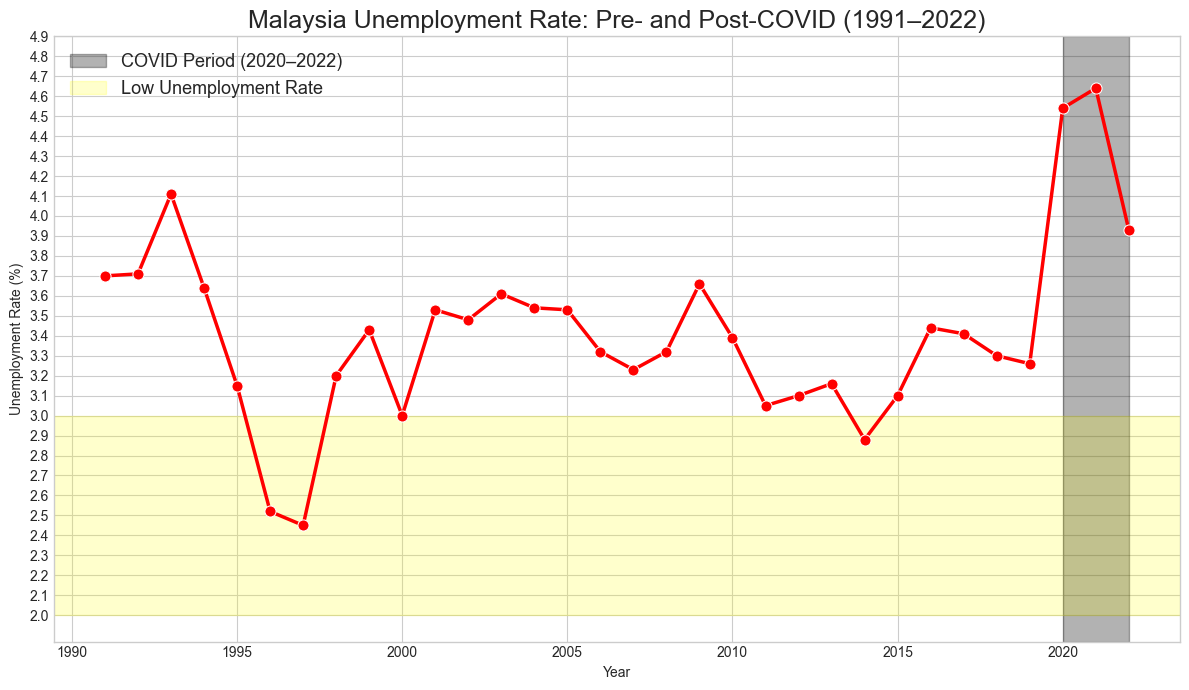

In [6]:
#TIME-SERIES TREND(unemployment rate )(Time Series = lineplot)
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=df_malaysia, x='Year', y='Unemployment Rate',
    color='red', linewidth=2.5, marker='o', markersize=8, ax=ax)

ax.axvspan(2020, 2022, color='black', alpha=0.3, label='COVID Period (2020–2022)')#shade the vertical area for covid period
ax.axhspan(2, 3.0, color='yellow',alpha=0.2, label="Low Unemployment Rate ")#shade the horizontal area for low unemployment rate 
ax.set_yticks(np.arange(2,5,0.1))
ax.set_title('Malaysia Unemployment Rate: Pre- and Post-COVID (1991–2022)', fontsize=18)
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend(fontsize=13)
plt.tight_layout()
plt.savefig(IMAGE_DIR_02 / "malaysia_unemployment_trend.png", dpi=300)
plt.show()